# Walk forward validation et tracking metrics

Ce notebook sert de benchmark de performance pour les trois modèles entrainés. Les métriques de comparaison sont :
- RMSE ;
- MAE ;
- SMAPE ;
- Skill Score over persistance


Il sera aussi comparé des métriques sur tous les horizons. Enfin, deux périmètres importants seront extraits pour comparer la performance des modèles sur ces périmètres :
- Temps nuageux (cloud_cover > 50) ;
- Par saison ;

In [1]:
# Import librairies
# Registry
import mlflow
from mlflow.pyfunc import PythonModel
from dotenv import dotenv_values

# ML / DL
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

#Logs, typing, libraries standards
import logging 
import os
from math import inf
import joblib
import warnings
from typing import Dict, Any, Tuple, Union
from dataclasses import dataclass
import pandas as pd
from pathlib import Path
warnings.filterwarnings("ignore")

# Config basique logging
PROJECT_ROOT = Path().resolve().parent
os.chdir(PROJECT_ROOT)
import src

d:\Anaconda\envs\solar_forecasting\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def init_mlflow(config: dict, experiment_name: str) -> None:
    """
    MLFlow initializing
    """
    os.environ["MLFLOW_TRACKING_USERNAME"] = config["MLFLOW_TRACKING_USERNAME"]
    os.environ["MLFLOW_TRACKING_PASSWORD"] = config["MLFLOW_TRACKING_PASSWORD"]
    mlflow.set_tracking_uri(config["MLFLOW_TRACKING_URI"])
    mlflow.set_experiment(experiment_name=experiment_name)

In [3]:
# Data core
df = pd.read_parquet(PROJECT_ROOT / "data/processed/training_pipeline_tests/final_training_dataset.parquet")
df.index = pd.to_datetime(df.index, utc=True).tz_convert("Europe/Paris")
meteo_features = joblib.load(PROJECT_ROOT / "data/processed/features/meteo_features.pkl")

# Features
X = df.drop(columns="solaire")
y = df["solaire"]

# Séparation train test split
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.20,
                                                    shuffle=False, 
                                                    random_state=42)

# Configuratio secrets
config = dotenv_values(PROJECT_ROOT / ".env")

In [47]:
y_quantile = y.rolling(90*24).quantile(0.99)

In [4]:
model_name = "Solar_MultiHorizon_Forecaster"
alias = "champion"
model_uri = f"models:/{model_name}@{alias}"
loaded_model = mlflow.pyfunc.load_model(model_uri)

In [ ]:

loaded_model.predict(X_test.iloc[0:1])

,+1h,+2h,+3h,+4h,+5h,+6h,+7h,+8h,+9h,+10h,...,+15h,+16h,+17h,+18h,+19h,+20h,+21h,+22h,+23h,+24h
date_heure,,,,,,,,,,,,,,,,,,,,,
2024-12-31 20:00:00+01:00,0.000162,0.00026,0.000863,0.0,0.000142,0.000666,0.0,0.001618,0.0,0.0,...,0.55253,0.609486,0.720807,0.60561,0.440526,0.192171,0.053444,0.013266,0.001282,0.0


In [49]:
# Rolling quantile
from pipelines.quantile_update_pipeline import RollingQuantile
from src.utils.config import SolarSettings

## Walk forward validation

En premier lieu, nous mettons en place une fonction de walk forward simple sur le dataset de test.

In [50]:
def rmse(y_true: pd.Series, y_pred: pd.Series) -> Any:
    """Return rmse of y_true and y_prec"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [51]:
class PersistenceBaseline:
    """Baseline lag-24h : demain = aujourd'hui."""
    
    def predict(self, window: pd.Series) -> pd.DataFrame:
        last_24 = window.iloc[-24:].values  
        
        horizon_cols = [f"H+{h}" for h in range(1, 25)]
        return pd.DataFrame(
            [last_24],
            columns=horizon_cols
        )

In [52]:
def lstm_inference(wrapped_lstm, X_test: pd.DataFrame, y_past: pd.Series):

    assert len(X_test) == 72
    assert len(y_past) == 48
    input_dict = {}
    input_dict["X"] = X_test
    input_dict["y_past"] = y_past
    
    return wrapped_lstm.predict([input_dict])

In [115]:
def walk_forward_eval(
    input_dataset: pd.DataFrame,
    true_values: pd.Series,
    y_quantile: pd.Series,
    wrapped_model,
    model_input_length: int,
    minimal_window: int,
    stride: int
):

    observed_values, predictions = [], []

    for step in tqdm(range(minimal_window, len(true_values) - model_input_length, stride)):

        window = input_dataset.iloc[step - 1:step] 
        q99 = y_quantile[window.index].values

        if isinstance(wrapped_model, PersistenceBaseline):
            y_hat = wrapped_model.predict(true_values.iloc[:step]).values.flatten()
        else:
            y_hat = wrapped_model.predict(window).values.flatten() * q99

        y_true = true_values.iloc[step:step + model_input_length].values

        observed_values.append(y_true)
        predictions.append(y_hat)

    return np.array(observed_values), np.array(predictions)

In [116]:
def compute_metrics(
    observed_values: np.ndarray,  
    predictions: np.ndarray,      
    baseline_predictions: np.ndarray,
) -> Dict[str, Any]:
    
    err      = observed_values - predictions
    err_base = observed_values - baseline_predictions

    # Metrics
    rmse_global  = np.sqrt(np.mean(err**2))
    mae_global   = np.mean(np.abs(err))
    rmse_base    = np.sqrt(np.mean(err_base**2))
    skill_score  = 1 - rmse_global / rmse_base

    # Par horizon
    horizon_idx          = [f"H+{h}" for h in range(1, 25)]
    rmse_per_horizon     = pd.Series(np.sqrt(np.mean(err**2, axis=0)), index=horizon_idx)
    mae_per_horizon      = pd.Series(np.mean(np.abs(err), axis=0), index=horizon_idx)
    ss_per_horizon       = pd.Series(1 - np.sqrt(np.mean(err**2, axis=0)) / np.sqrt(np.mean(err_base**2, axis=0)),
        index=horizon_idx)

    return {
        "RMSE":             rmse_global,
        "MAE":              mae_global,
        "SkillScore":       skill_score,
        "RMSE_per_horizon": rmse_per_horizon,
        "MAE_per_horizon":  mae_per_horizon,
        "SS_per_horizon":   ss_per_horizon,
    }

In [ ]:
baseline = PersistenceBaseline()
obs, preds_base = walk_forward_eval(
    input_dataset=X_test, 
    true_values=y_test, 
    y_quantile=y_quantile,
    wrapped_model=baseline,
    model_input_length=24,
    minimal_window=48,
    stride=1
) 

obs, preds_lgbm = walk_forward_eval(
    input_dataset=X_test, 
    true_values=y_test, 
    y_quantile=y_quantile,
    wrapped_model=loaded_model,
    model_input_length=24,
    minimal_window=48,
    stride=1
)

 48%|████▊     | 4145/8669 [00:03<00:03, 1143.99it/s]


KeyboardInterrupt: 

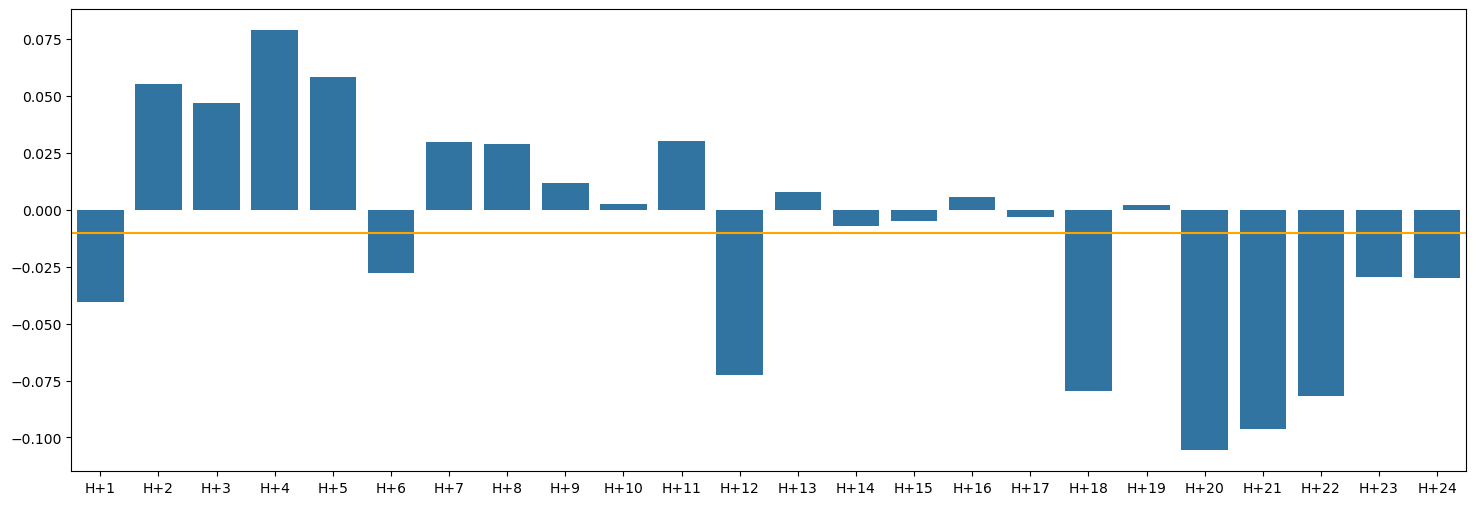

In [114]:
metrics_lgbm = compute_metrics(obs, preds_lgbm, preds_base)
fig = plt.figure(figsize=(18, 6))
sns.barplot(metrics_lgbm["SS_per_horizon"])
plt.axhline(y=metrics_lgbm["SkillScore"], color="orange")